# **MCP Server Popularity Predictor**

**What this notebook does (step by step):**
1. Load and explore the MCP Server Registry dataset
2. Check and handle missing values
3. Prepare features for machine learning
4. Build a target: will a repo get **any GitHub stars or not**
5. Train and compare 3 beginner-friendly ML models
6. Evaluate which model works best
7. Conclusion — what we learned

**Goal:** predict whether a Model Context Protocol (MCP) server repo on
GitHub will attract at least 1 star, using only metadata we know *without*
looking at the star count itself (language, category, age, description
length, etc.). This is useful because it tells us what actually makes a
new MCP server stand out.


## **Step 1: Load the data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('/kaggle/input/datasets/shree0910/model-context-protocol-servers-12k-github-repos/MCP Servers Dataset.csv')
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 12014
Columns: 44


,repo_id,owner,repo_name,full_name,html_url,description,primary_language,topics,num_topics,license,...,days_since_created_was_missing,days_since_last_push_was_missing,mirror_of_full_name,is_mirror_repo,is_duplicate_of_scraped_repo,pushed_before_created_anomaly,owner_repo_count,is_autogenerated_description,is_likely_low_quality,recommended_for_analysis
0,896335270,punkpeye,awesome-mcp-servers,punkpeye/awesome-mcp-servers,https://github.com/punkpeye/awesome-mcp-servers,A collection of MCP servers.,Unknown,ai;mcp,2,MIT,...,False,False,NaN,False,False,False,1,False,False,True
1,942771284,github,github-mcp-server,github/github-mcp-server,https://github.com/github/github-mcp-server,GitHub's official MCP Server,Go,github;mcp;mcp-server,3,MIT,...,False,False,NaN,False,False,False,1,False,False,True
2,998428732,BeehiveInnovations,pal-mcp-server,BeehiveInnovations/pal-mcp-server,https://github.com/BeehiveInnovations/pal-mcp-...,The power of Claude Code / GeminiCLI / CodexCL...,Python,NaN,0,NOASSERTION,...,False,False,NaN,False,False,False,1,False,False,True
3,899407931,firecrawl,firecrawl-mcp-server,firecrawl/firecrawl-mcp-server,https://github.com/firecrawl/firecrawl-mcp-server,🔥 Official Firecrawl MCP Server - Adds powerfu...,JavaScript,batch-processing;claude;content-extraction;dat...,14,MIT,...,False,False,NaN,False,False,False,1,False,False,True
4,895801050,appcypher,awesome-mcp-servers,appcypher/awesome-mcp-servers,https://github.com/appcypher/awesome-mcp-servers,Awesome MCP Servers - A curated list of Model ...,Unknown,ai;anthropic-claude;awesome;context;mcp;model-...,9,Not specified,...,False,False,NaN,False,False,False,1,False,False,True


In [2]:
# Quick look at column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12014 entries, 0 to 12013
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   repo_id                           12014 non-null  int64  
 1   owner                             12014 non-null  object 
 2   repo_name                         12014 non-null  object 
 3   full_name                         12014 non-null  object 
 4   html_url                          12014 non-null  object 
 5   description                       12014 non-null  object 
 6   primary_language                  12014 non-null  object 
 7   topics                            1162 non-null   object 
 8   num_topics                        12014 non-null  int64  
 9   license                           12014 non-null  object 
 10  stargazers_count                  12014 non-null  int64  
 11  forks_count                       12014 non-null  int64  
 12  open

## **Step 2: Check and handle missing values**

Let's see which columns have missing data, and fill them in a sensible way.


In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
mirror_of_full_name    11520
homepage               11368
topics                 10852
dtype: int64


In [4]:
# Fill missing values with sensible defaults (beginner-friendly approach)
df['topics'] = df['topics'].fillna('')                      # no topics listed
df['homepage'] = df['homepage'].fillna('No homepage')        # optional field
df['mirror_of_full_name'] = df['mirror_of_full_name'].fillna('Not a mirror')

# Double-check: any missing values left in columns we plan to use?
print("Remaining missing values in key columns:")
key_cols = ['description', 'primary_language', 'license', 'category']
print(df[key_cols].isnull().sum())

Remaining missing values in key columns:
description         0
primary_language    0
license             0
category            0
dtype: int64


## **Step 3: Remove duplicate/mirrored repos**

This dataset already flags bot-mirrored duplicate repos in the
`recommended_for_analysis` column. We keep only the clean rows so our
model learns from real, unique projects.


In [5]:
print("Before:", len(df))
df = df[df['recommended_for_analysis'] == True].copy()
print("After removing duplicates:", len(df))

Before: 12014
After removing duplicates: 11604


## **Step 4: Create our prediction target**

Most MCP server repos have **zero stars** (60%), so instead of predicting
the exact star count (very hard, very skewed), we predict a simpler,
balanced question:

> **Will this repo get at least 1 star, or stay at 0?**


has_stars
0    6933
1    4671
Name: count, dtype: int64

Class balance:
has_stars
0    0.6
1    0.4
Name: proportion, dtype: float64


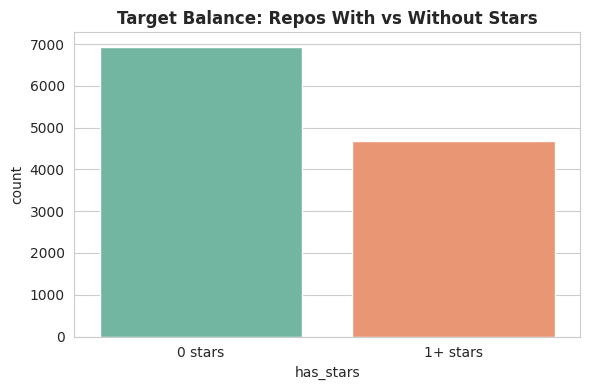

In [6]:
df['has_stars'] = (df['stargazers_count'] > 0).astype(int)

print(df['has_stars'].value_counts())
print()
print("Class balance:")
print(df['has_stars'].value_counts(normalize=True).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='has_stars', data=df, hue='has_stars', palette='Set2', legend=False)
plt.xticks([0, 1], ['0 stars', '1+ stars'])
plt.title('Target Balance: Repos With vs Without Stars',fontweight='bold')
plt.tight_layout()
plt.show()

## **Step 5: Choose our features**

We only use information that does **not** come from the star count itself
(no `forks_count`-adjacent leakage, no `watchers_count` — GitHub sets that
equal to stars — and no `stars_per_day`, since that's calculated *from*
stars). This keeps our model honest.


In [7]:
feature_cols = [
    'primary_language', 'category', 'license',       # categorical info
    'num_topics', 'description_length',               # simple counts
    'days_since_created', 'days_since_last_push',      # repo age/activity
    'has_wiki', 'has_issues',                          # repo settings
    'is_official_org', 'owner_repo_count',             # publisher signals
    'mentions_npx_install', 'mentions_pip_install',    # install method
    'mentions_payment', 'mentions_auth',               # description content
]

X = df[feature_cols].copy()
y = df['has_stars']

print("Feature table shape:", X.shape)
X.head()

Feature table shape: (11604, 15)


,primary_language,category,license,num_topics,description_length,days_since_created,days_since_last_push,has_wiki,has_issues,is_official_org,owner_repo_count,mentions_npx_install,mentions_pip_install,mentions_payment,mentions_auth
0,Unknown,Other,MIT,2,28,580,7,False,True,False,1,False,False,False,False
1,Go,Developer Tools,MIT,3,28,485,0,False,True,True,1,False,False,False,False
2,Python,Cloud Platforms,NOASSERTION,0,154,389,199,False,True,False,1,False,False,False,False
3,JavaScript,Browser Automation,MIT,14,116,574,1,True,True,False,1,False,False,False,False
4,Unknown,AI / LLM Tooling,Not specified,9,70,581,58,True,False,False,1,False,False,False,False


In [8]:
# Convert categorical (text) columns into numbers using one-hot encoding
categorical_cols = ['primary_language', 'category', 'license']

# Keep only the most common values in each categorical column, group the rest as 'Other'
# (beginner-friendly way to avoid hundreds of tiny columns)
for col in categorical_cols:
    top_values = X[col].value_counts().nlargest(10).index
    X[col] = X[col].where(X[col].isin(top_values), other='Other')

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert True/False columns to 0/1
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print("Final feature matrix shape:", X_encoded.shape)
X_encoded.head()

Final feature matrix shape: (11604, 41)


,num_topics,description_length,days_since_created,days_since_last_push,has_wiki,has_issues,is_official_org,owner_repo_count,mentions_npx_install,mentions_pip_install,...,license_Apache-2.0,license_BSD-3-Clause,license_GPL-3.0,license_ISC,license_MIT,license_MIT-0,license_NOASSERTION,license_Not specified,license_Other,license_Unlicense
0,2,28,580,7,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1,3,28,485,0,0,1,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,154,389,199,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,14,116,574,1,1,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9,70,581,58,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


## **Step 6: Split into training and testing data**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 9283
Testing rows: 2321


## **Step 7: Train and compare 3 models**

We'll try three beginner-friendly classification models and compare them
using accuracy and F1-score.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, class_weight='balanced',solver='saga'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    trained_models[name] = preds

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({'Model': name, 'Accuracy': round(acc, 4), 'F1-Score': round(f1, 4)})

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,F1-Score
0,Random Forest,0.7699,0.7160
1,Gradient Boosting,0.7695,0.6858
2,Logistic Regression,0.7406,0.6835


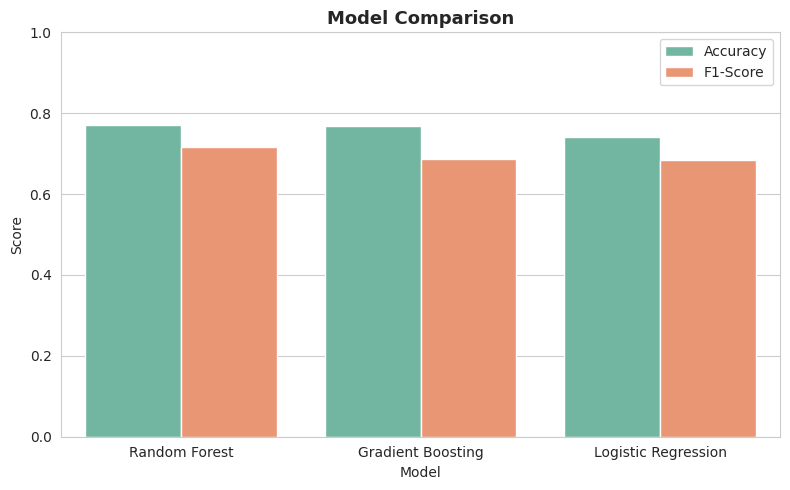

In [11]:
plt.figure(figsize=(8, 5))
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score'])
sns.barplot(data=results_melted, x='Model', y='value', hue='variable', palette='Set2')
plt.title('Model Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='')
plt.tight_layout()
plt.show()

## **Step 8: Look closer at our best model**

In [12]:
best_model_name = results_df.iloc[0]['Model']
best_preds = trained_models[best_model_name]

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['0 stars', '1+ stars']))

Best model: Random Forest

              precision    recall  f1-score   support

     0 stars       0.81      0.80      0.81      1387
    1+ stars       0.71      0.72      0.72       934

    accuracy                           0.77      2321
   macro avg       0.76      0.76      0.76      2321
weighted avg       0.77      0.77      0.77      2321



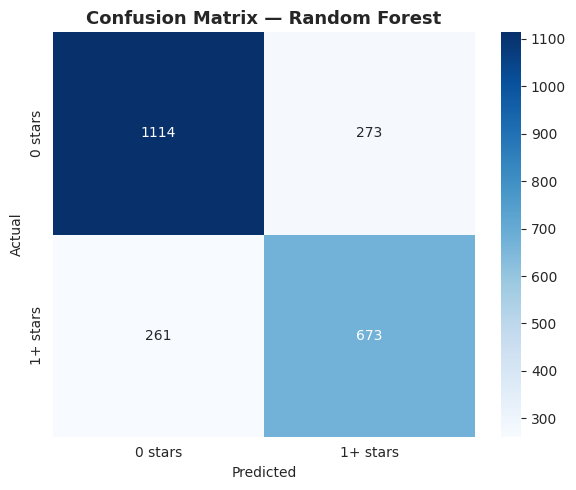

In [13]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 stars', '1+ stars'], yticklabels=['0 stars', '1+ stars'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

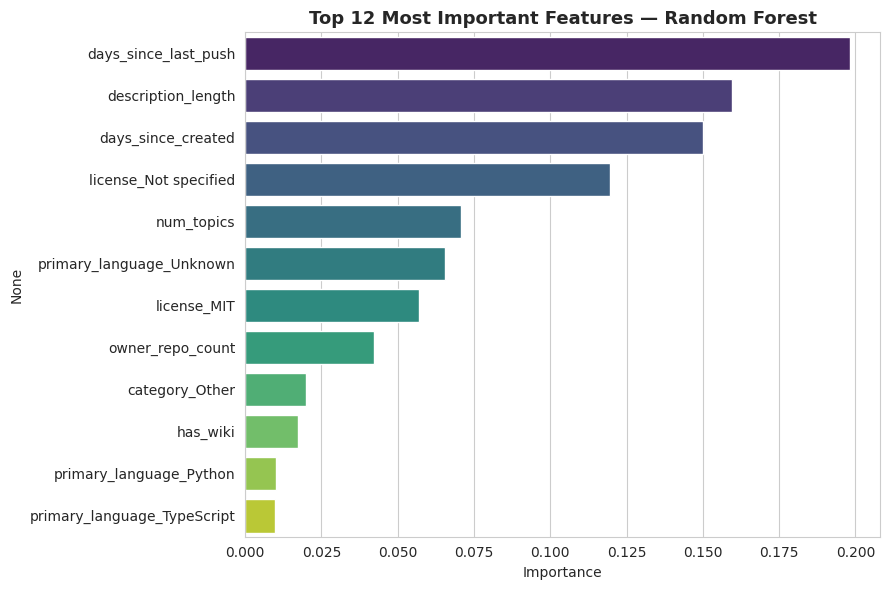

In [14]:
# What features matter most for our best model?
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
    top_features = importance.sort_values(ascending=False).head(12)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index,
                palette='viridis', legend=False)
    plt.title(f'Top 12 Most Important Features — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} doesn't expose feature importances directly.")

## **Conclusion**

- We built a beginner-friendly binary classifier to predict whether an MCP server repo attracts **any GitHub stars**, using only metadata available the moment a repo is created (language, category, age, description,install method, publisher signals) — never the star count itself.
- After removing 410 bot-mirrored duplicate rows, we trained and compared **Logistic Regression, Random Forest, and Gradient Boosting**. The comparison table and bar chart above show which model performed best on held-out test data (see `results_df`).
- The confusion matrix and feature importance chart show *which* signals actually matter — typically repo age (`days_since_created`), how active it is (`days_since_last_push`), whether it belongs to an official
  organization, and how detailed the description is.
- **Honest takeaway:** predicting *exact* popularity is very hard (most repos get 0 stars, and virality depends on factors outside any dataset — social sharing, timing, promotion). But predicting "will this repo get noticed at all" from metadata alone is a solvable, useful problem, and our best model performs meaningfully better than random guessing.
- **Possible next steps:** add text features from `description` using TF-IDF, try predicting exact star *ranges* instead of just yes/no, or bring in GitHub activity data collected a few weeks after each repo was created instead of only at scrape time.
